# Project onto Mediterranean PCA with projectPCA
This example file walks you through this standard PC projection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import socket as socket
import os as os
import sys as sys
import multiprocessing as mp

socket_name = socket.gethostname()
    
if socket_name.startswith("bionc") or socket_name.startswith("hpc"):
    print("Leipzig Cluster detected!")
    path = "/mnt/archgen/users/hringbauer/git/projectPCA/"   
    #path = "/mnt/archgen/users/hringbauer/"
else: 
    raise RuntimeWarning("Not compatible machine. Check!!")
     
os.chdir(path)  # Set the right Path (in line with Atom default)
print(os.getcwd())
print(f"CPU Count: {mp.cpu_count()}")
print(sys.version_info)

### Uncomment for local version:
from projectPCA.run import project_eigenstrat

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

Leipzig Cluster detected!
/mnt/archgen/users/hringbauer/git/projectPCA
CPU Count: 128
sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


### Project single individual
The PCs are saved in the df_out dataframe

I18193 is a North African Punic individual

The important thing is to set maf=0.001, which is the minor allele Frequency cutoff for the Punic PCA.

# 1) Plot single individuals

Local Version
Eigenstrat packed: True
Loaded Eigenstrat File set with 208 Individuals and 1207104 SNPs.
Filtering 20669 / 518785 SNPs with MAF<0.001.


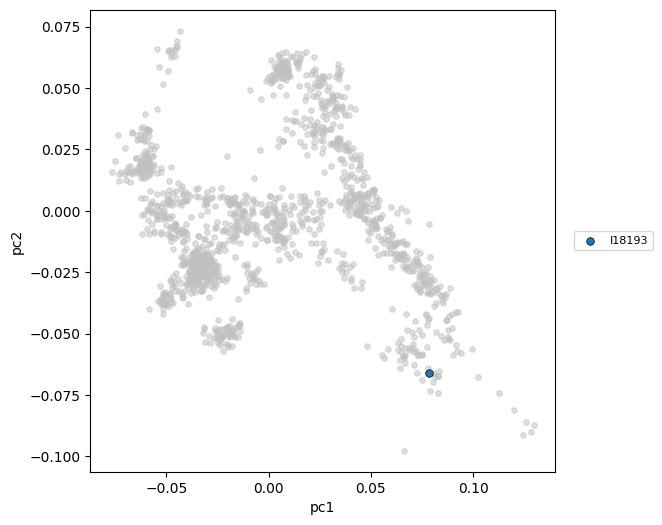

CPU times: user 5.93 s, sys: 468 ms, total: 6.4 s
Wall time: 6.42 s


In [3]:
%%time
df_out = project_eigenstrat(es_path="/mnt/archgen/users/hringbauer/data/ringbauer2025_es/punic208.v54.3_1240k",
                            iids = ["I18193"], es_type="default", pca="MED", maf=0.001,
                            fig_path='./figs/punic_I18193.png')

### Plot multiple samples, with background colours turned on
- I18199: Greek Ancestry iid (from Villaricos)
- I21966: On North African cline (Tharros)
- I22115: Sicilian-Aegean (Tharros)
The `plot_bgrd_c=True` turns on the colours of Mediterranean IA populations

Local Version
Eigenstrat packed: True
Loaded Eigenstrat File set with 208 Individuals and 1207104 SNPs.
Filtering 20669 / 518785 SNPs with MAF<0.001.


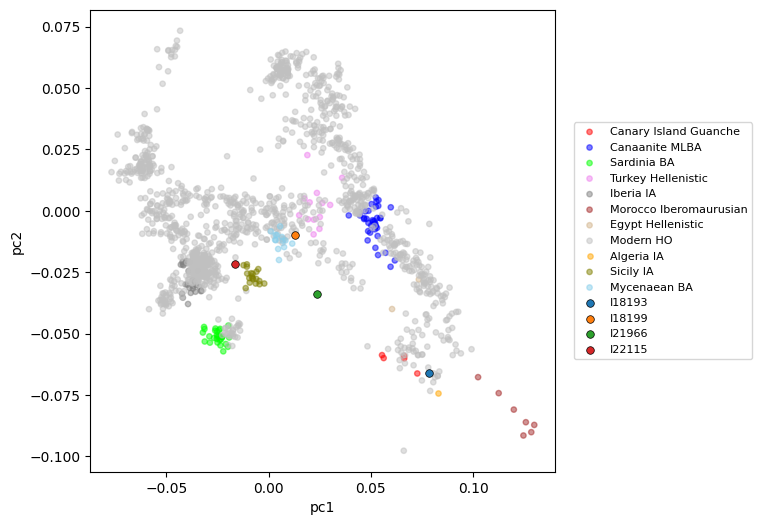

CPU times: user 6.2 s, sys: 429 ms, total: 6.62 s
Wall time: 6.72 s


In [6]:
%%time
df_out = project_eigenstrat(es_path="/mnt/archgen/users/hringbauer/data/ringbauer2025_es/punic208.v54.3_1240k",
                            iids = ["I18193", "I18199", "I21966", "I22115"], es_type="default", pca="MED", 
                            plot_bgrd_c=True, maf=0.001,
                            fig_path='')

### Now try Takakori

Local Version
Eigenstrat packed: False
3 Eigenstrat Files with 1 Individuals and 1233013 SNPs
Filtering 142611 / 532069 SNPs with MAF<0.05.


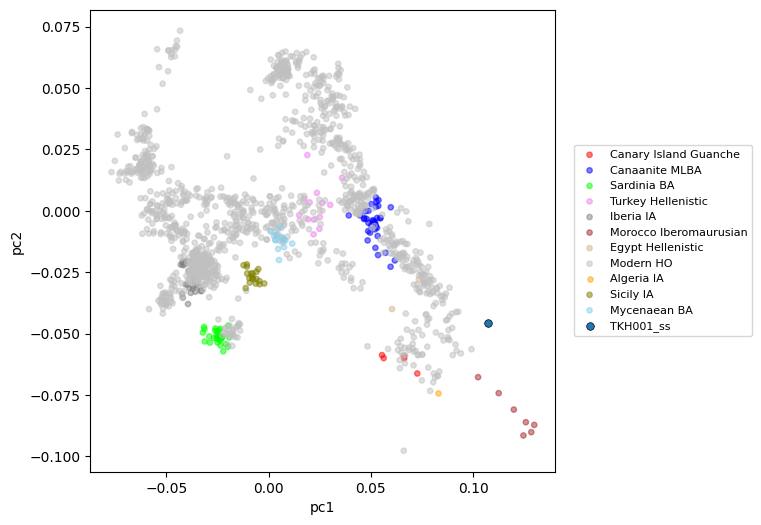

CPU times: user 7.94 s, sys: 569 ms, total: 8.51 s
Wall time: 8.59 s


,pc1,pc2,#SNP,iid
0,0.107355,-0.045583,424399,TKH001_ss


In [8]:
%%time
project_eigenstrat(es_path="/mnt/archgen/Autorun_eager/eager_outputs/RP/TKH/TKH001/genotyping/pileupcaller.single",
                   iids=["TKH001_ss"], pca="MED", es_type="default", plot_bgrd_c=True)

# 2) Custom Plotting
For your own plots, you can load the background data, and then use the above code to get PC coordinates of new samples.

You can then save and use those PC coordinate tables to plot PC1/PC2 in any program you like

In [9]:
from projectPCA.get_proj_files import get_projection_files 

In [15]:
pf = get_projection_files(mode="MED")
df_bgrd_pcs = pf.get_projections_ref()

In [16]:
df_bgrd_pcs.head()

,pc1,pc2,#SNP,iid,pop,c
0,0.009091,0.057351,526832,Adg-185.HO,Modern HO,silver
1,0.003784,0.058197,526844,Adg-192.HO,Modern HO,silver
2,0.003929,0.055941,527125,Adg-194.HO,Modern HO,silver
3,-0.003516,0.045605,526655,Adg-222.HO,Modern HO,silver
4,0.006944,0.056935,526345,Adg-224.HO,Modern HO,silver


In [18]:
df_ho = df_bgrd_pcs[df_bgrd_pcs["pop"]=="Modern HO"] # Extract Modern HO Samples

### Manual Plot

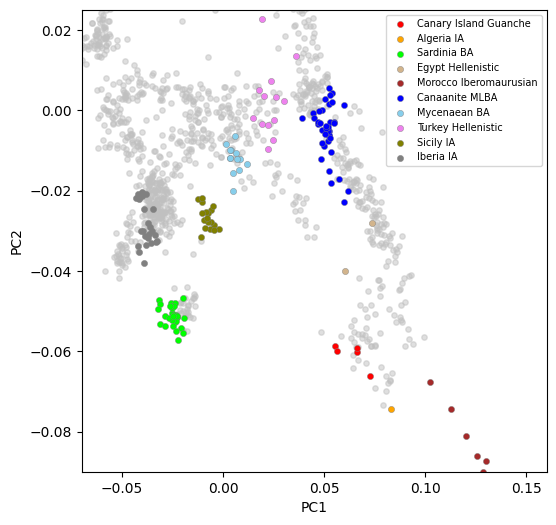

In [24]:
ls=["Canary Island Guanche", "Algeria IA", "Sardinia BA", "Egypt Hellenistic", "Morocco Iberomaurusian", 
    "Canaanite MLBA", "Mycenaean BA", "Turkey Hellenistic", "Sicily IA", "Iberia IA"]

cs=["red", "orange", "lime", "tan", "brown",
   "blue", "skyblue", "violet", "olive", "gray"] #"maroon", "yellow", "orange", "deeppink", "brown", "blue", "salmon", 
    #"pink", "violet", "magenta", "black", "saddlebrown", 
    #"dimgray", "silver", "royalblue", "aqua", "ivory", "plum", "fuchsia"]

plt.figure(figsize=(6,6))
ax = plt.gca()

ax.scatter(df_ho["pc1"], df_ho["pc2"], c="silver", s=15, alpha=0.5)

for l,c in zip(ls,cs):
    dft= df_bgrd_pcs[df_bgrd_pcs["pop"].str.contains(l)]
    ax.scatter(dft["pc1"], dft["pc2"], c=c, s=20, label=l,
               edgecolor="gray", lw=0.3)

ax.legend(loc="upper right", fontsize=7, ncol=1)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_ylim([-0.09,0.025])
ax.set_xlim([-0.07,0.16])
plt.show()